## Imports

In [2]:
import numpy as np
import pandas as pd
import sys
sys.path.append("../src")
from utils import get_target_data

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from utils import cross_validate_target

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform



## Load Processed Data

In [3]:
X = np.load("../data/processed/X_morgan.npy")
y = np.load("../data/processed/y_targets.npy")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (7831, 2048)
y shape: (7831, 12)


## Test Data Preparation on NR-AR

In [4]:
targets = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
           'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
           'SR-HSE', 'SR-MMP', 'SR-p53']

X_train, X_test, y_train, y_test, class_weights = get_target_data(X, y, target_idx=0)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train positive rate: {y_train.mean()*100:.1f}%")
print(f"y_test positive rate:  {y_test.mean()*100:.1f}%")
print(f"Class weights: {class_weights}")

X_train: (5812, 2048)
X_test:  (1453, 2048)
y_train positive rate: 4.2%
y_test positive rate:  4.3%
Class weights: {0: np.float64(0.5221922731356694), 1: np.float64(11.765182186234817)}


## Define Targets and Models


In [5]:
targets = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
           'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
           'SR-HSE', 'SR-MMP', 'SR-p53']

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost":       XGBClassifier(n_estimators=200, eval_metric='auc', random_state=42, verbosity=0),
    "Logistic Reg":  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}



## Cross-Validation Model Functions

In [6]:
def rf_fn(cw_dict, y_train):
    return RandomForestClassifier(n_estimators=200, class_weight=cw_dict, random_state=42, n_jobs=-1)

def lr_fn(cw_dict, y_train):
    return LogisticRegression(class_weight=cw_dict, max_iter=1000, random_state=42)

def xgb_fn(cw_dict, y_train):
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    return XGBClassifier(n_estimators=200, scale_pos_weight=neg/pos, eval_metric='auc', random_state=42, verbosity=0)

print("Model functions defined!")

Model functions defined!


## Baseline Comparison (single 80/20 split — kept for reference only)

*Note: these scores come from one train/test split and can vary by chance. The Cross-Validation section below is the trustworthy evaluation used for model selection.*

In [7]:
results = []

for i, target in enumerate(targets):
    print(f"Training on {target}...")
    
    X_train, X_test, y_train, y_test, class_weights = get_target_data(X, y, target_idx=i)
    
    for model_name, model in models.items():
        # Handle XGBoost class weight differently
        if model_name == "XGBoost":
            neg = (y_train == 0).sum()
            pos = (y_train == 1).sum()
            model.set_params(scale_pos_weight=neg/pos)
        
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        
        results.append({
            "Target":    target,
            "Model":     model_name,
            "ROC-AUC":   round(roc_auc_score(y_test, proba), 3),
            "PR-AUC":    round(average_precision_score(y_test, proba), 3),
        })

print("\nAll done!")

Training on NR-AR...


Training on NR-AR-LBD...
Training on NR-AhR...
Training on NR-Aromatase...
Training on NR-ER...
Training on NR-ER-LBD...
Training on NR-PPAR-gamma...
Training on SR-ARE...
Training on SR-ATAD5...
Training on SR-HSE...
Training on SR-MMP...
Training on SR-p53...

All done!


## Cross-Validation Results (5-Fold Stratified) — primary evaluation

In [8]:
cv_results = []

model_fns = {
    "Random Forest": rf_fn,
    "XGBoost": xgb_fn,
    "Logistic Reg": lr_fn,
}

for i, target in enumerate(targets):
    print(f"CV on {target}...")
    for model_name, fn in model_fns.items():
        res = cross_validate_target(X, y, target_idx=i, model_fn=fn, n_splits=5)
        cv_results.append({
            "Target": target,
            "Model": model_name,
            "ROC-AUC mean": round(res["roc_auc_mean"], 3),
            "ROC-AUC std":  round(res["roc_auc_std"], 3),
            "PR-AUC mean":  round(res["pr_auc_mean"], 3),
            "PR-AUC std":   round(res["pr_auc_std"], 3),
            "Accuracy mean": round(res["accuracy_mean"], 3),
            "Confusion Matrix": res["confusion_matrix"],
        })

print("\nAll CV done!")

CV on NR-AR...
CV on NR-AR-LBD...
CV on NR-AhR...
CV on NR-Aromatase...
CV on NR-ER...
CV on NR-ER-LBD...
CV on NR-PPAR-gamma...
CV on SR-ARE...
CV on SR-ATAD5...
CV on SR-HSE...
CV on SR-MMP...
CV on SR-p53...

All CV done!


## View CV Results Table

In [9]:
df_cv = pd.DataFrame(cv_results)
print(df_cv[["Target", "Model", "ROC-AUC mean", "ROC-AUC std", "PR-AUC mean", "PR-AUC std"]])

           Target          Model  ROC-AUC mean  ROC-AUC std  PR-AUC mean  \
0           NR-AR  Random Forest         0.786        0.028        0.524   
1           NR-AR        XGBoost         0.765        0.030        0.510   
2           NR-AR   Logistic Reg         0.771        0.029        0.495   
3       NR-AR-LBD  Random Forest         0.849        0.010        0.637   
4       NR-AR-LBD        XGBoost         0.849        0.023        0.608   
5       NR-AR-LBD   Logistic Reg         0.856        0.014        0.593   
6          NR-AhR  Random Forest         0.890        0.014        0.608   
7          NR-AhR        XGBoost         0.872        0.014        0.600   
8          NR-AhR   Logistic Reg         0.859        0.012        0.549   
9    NR-Aromatase  Random Forest         0.821        0.030        0.409   
10   NR-Aromatase        XGBoost         0.778        0.045        0.393   
11   NR-Aromatase   Logistic Reg         0.778        0.041        0.336   
12          

## Save CV Results

In [10]:
df_cv.to_csv("../reports/cv_results.csv", index=False)
print("CV results saved!")

CV results saved!


## CV ROC-AUC Heatmap (mean across 5 folds)

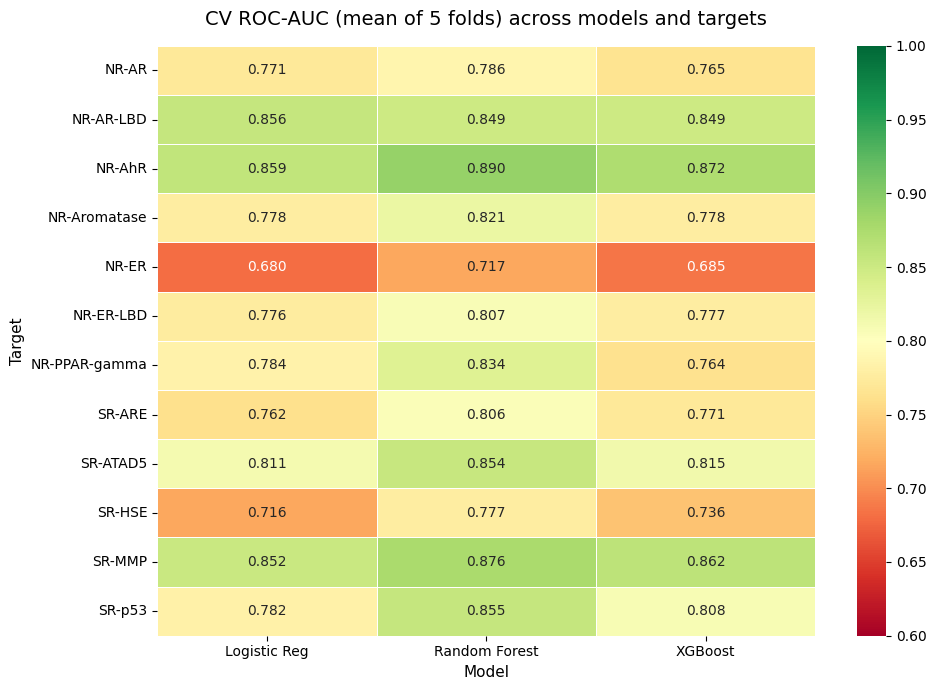

Saved!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df_cv_pivot_roc = df_cv.pivot_table(index='Target', columns='Model', values='ROC-AUC mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_cv_pivot_roc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.6, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("CV ROC-AUC (mean of 5 folds) across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/cv_roc_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

## CV PR-AUC Heatmap (mean across 5 folds)

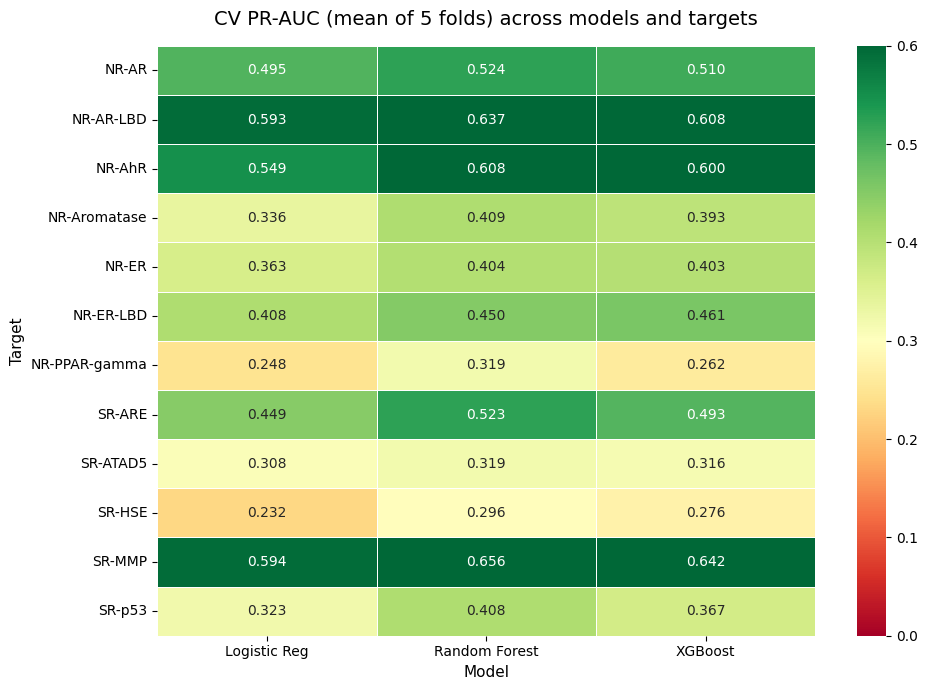

Saved!


In [12]:
df_cv_pivot_pr = df_cv.pivot_table(index='Target', columns='Model', values='PR-AUC mean')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_cv_pivot_pr, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.0, vmax=0.6, linewidths=0.5, ax=ax)
ax.set_title("CV PR-AUC (mean of 5 folds) across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/cv_pr_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

## CV Stability Check (std across folds)

Low std = stable model. High std = score is sensitive to which molecules end up in the fold — worth flagging in the report.

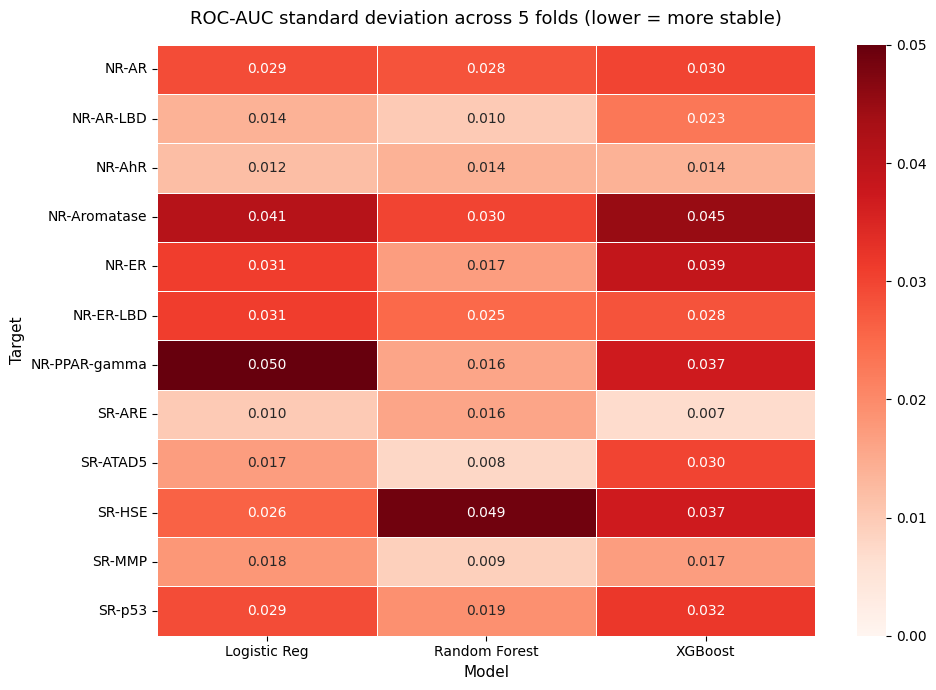

Saved!


In [13]:
df_cv_pivot_std = df_cv.pivot_table(index='Target', columns='Model', values='ROC-AUC std')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_cv_pivot_std, annot=True, fmt='.3f', cmap='Reds',
            vmin=0.0, vmax=0.05, linewidths=0.5, ax=ax)
ax.set_title("ROC-AUC standard deviation across 5 folds (lower = more stable)", fontsize=13, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/cv_stability_heatmap.png", dpi=150)
plt.show()
print("Saved!")

## Baseline Heatmaps (single split — for contrast with CV results only)

In [14]:
df_results = pd.DataFrame(results)
df_pivot = df_results.pivot_table(index='Target', columns='Model', values='ROC-AUC')
df_pivot = df_pivot.round(3)
print(df_pivot)

Model          Logistic Reg  Random Forest  XGBoost
Target                                             
NR-AR                 0.735          0.741    0.714
NR-AR-LBD             0.799          0.794    0.790
NR-AhR                0.872          0.908    0.892
NR-Aromatase          0.840          0.871    0.814
NR-ER                 0.677          0.700    0.666
NR-ER-LBD             0.793          0.787    0.746
NR-PPAR-gamma         0.760          0.807    0.780
SR-ARE                0.770          0.823    0.787
SR-ATAD5              0.843          0.861    0.820
SR-HSE                0.721          0.799    0.718
SR-MMP                0.838          0.874    0.864
SR-p53                0.784          0.852    0.818


In [15]:
df_results.to_csv("../reports/model_comparison.csv", index=False)
print("Results saved!")

Results saved!


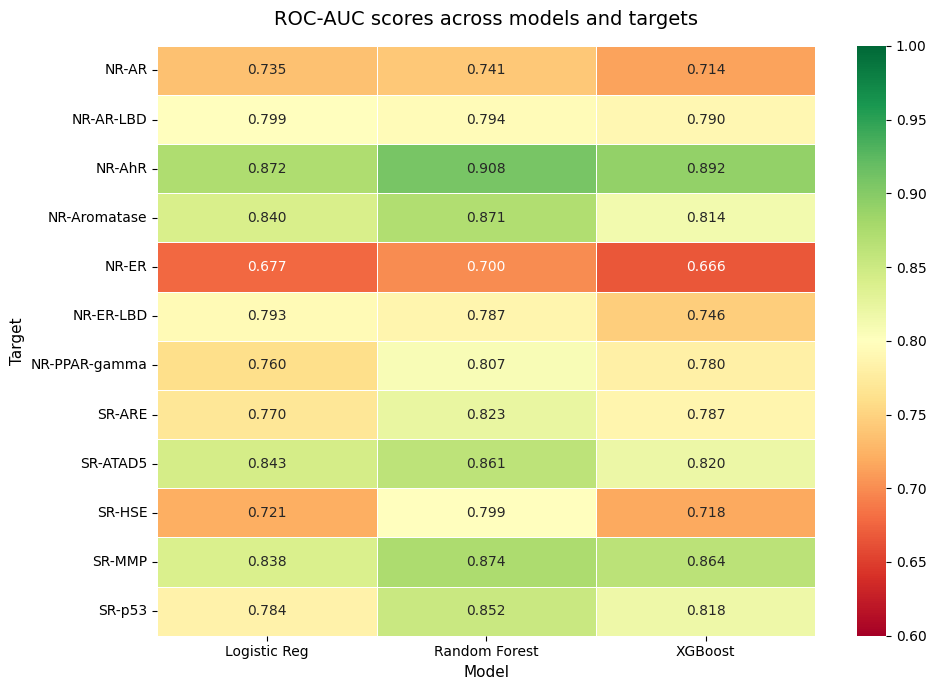

Saved!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(df_pivot, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0.6, vmax=1.0,
            linewidths=0.5,
            ax=ax)

ax.set_title("ROC-AUC scores across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/figures/roc_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

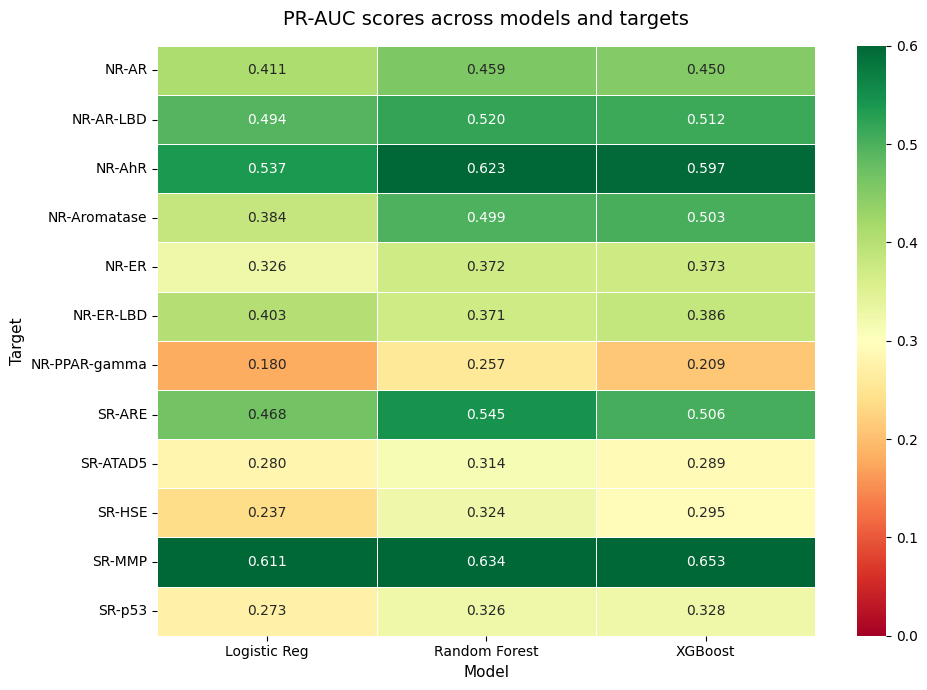

Saved!


In [17]:
df_pivot_pr = df_results.pivot_table(index='Target', columns='Model', values='PR-AUC')
df_pivot_pr = df_pivot_pr.round(3)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(df_pivot_pr, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            vmin=0.0, vmax=0.6,
            linewidths=0.5,
            ax=ax)

ax.set_title("PR-AUC scores across models and targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/figures/pr_auc_heatmap.png", dpi=150)
plt.show()
print("Saved!")

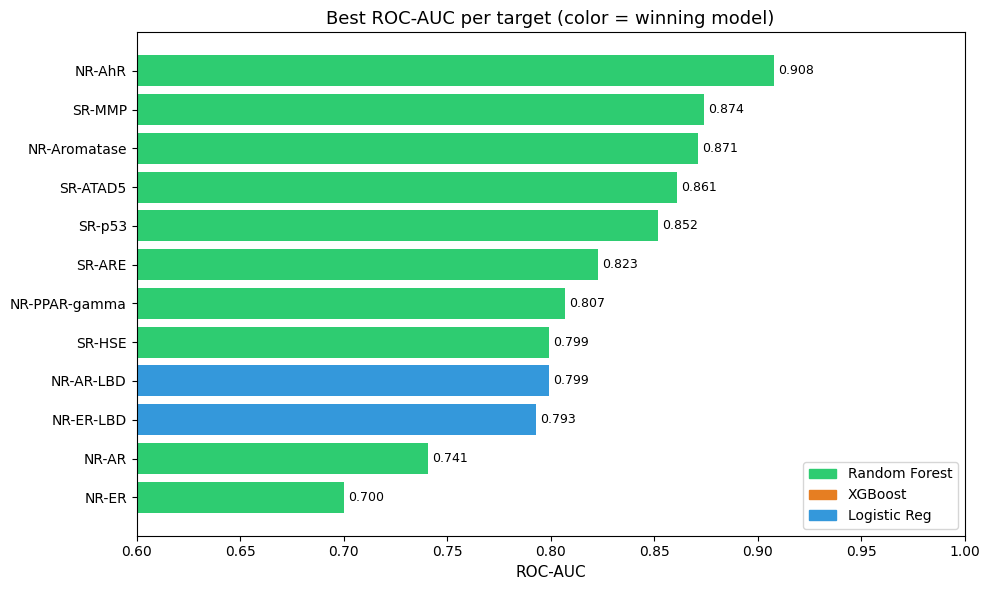

Saved!


In [18]:
best = df_results.loc[df_results.groupby('Target')['ROC-AUC'].idxmax()]
best = best.sort_values('ROC-AUC', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if m == 'Random Forest' else '#e67e22' if m == 'XGBoost' else '#3498db' 
          for m in best['Model']]

bars = ax.barh(best['Target'], best['ROC-AUC'], color=colors)

ax.set_xlim(0.6, 1.0)
ax.set_xlabel("ROC-AUC", fontsize=11)
ax.set_title("Best ROC-AUC per target (color = winning model)", fontsize=13)

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Random Forest'),
          Patch(color='#e67e22', label='XGBoost'),
          Patch(color='#3498db', label='Logistic Reg')]
ax.legend(handles=legend)

for bar, val in zip(bars, best['ROC-AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/best_model_per_target.png", dpi=150)
plt.show()
print("Saved!")

## Hyperparameter Tuning — XGBoost (RandomizedSearchCV across all targets)

We use `RandomizedSearchCV` instead of `GridSearchCV` — it samples a fixed number of random combinations instead of every possible one, getting most of the benefit in a fraction of the time. This is the standard choice when tuning across many targets under time constraints.

In [19]:
param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}
print("Search space defined!")

Search space defined!


In [20]:
best_xgb_params = {}
tuned_xgb_scores = {}

for i, target in enumerate(targets):
    print(f"Tuning XGBoost on {target}...")
    mask = ~np.isnan(y[:, i])
    X_t = X[mask]
    y_t = y[mask, i].astype(int)
    neg, pos = (y_t == 0).sum(), (y_t == 1).sum()

    xgb_base = XGBClassifier(scale_pos_weight=neg/pos, eval_metric='auc', random_state=42, verbosity=0)

    search = RandomizedSearchCV(
        xgb_base, param_dist,
        n_iter=20,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_t, y_t)

    best_xgb_params[target] = search.best_params_
    tuned_xgb_scores[target] = search.best_score_
    print(f"  -> Best ROC-AUC: {search.best_score_:.3f}")

print("\nAll targets tuned!")

Tuning XGBoost on NR-AR...
  -> Best ROC-AUC: 0.805
Tuning XGBoost on NR-AR-LBD...
  -> Best ROC-AUC: 0.860
Tuning XGBoost on NR-AhR...
  -> Best ROC-AUC: 0.883
Tuning XGBoost on NR-Aromatase...
  -> Best ROC-AUC: 0.813
Tuning XGBoost on NR-ER...
  -> Best ROC-AUC: 0.718
Tuning XGBoost on NR-ER-LBD...
  -> Best ROC-AUC: 0.795
Tuning XGBoost on NR-PPAR-gamma...
  -> Best ROC-AUC: 0.801
Tuning XGBoost on SR-ARE...
  -> Best ROC-AUC: 0.789
Tuning XGBoost on SR-ATAD5...
  -> Best ROC-AUC: 0.832
Tuning XGBoost on SR-HSE...
  -> Best ROC-AUC: 0.759
Tuning XGBoost on SR-MMP...
  -> Best ROC-AUC: 0.870
Tuning XGBoost on SR-p53...
  -> Best ROC-AUC: 0.828

All targets tuned!


## Default vs Tuned — XGBoost Comparison Table

This is the before/after evidence: default hyperparameters vs RandomizedSearchCV-tuned, both evaluated with 5-fold CV.

In [21]:
xgb_default_scores = df_cv[df_cv['Model'] == 'XGBoost'].set_index('Target')['ROC-AUC mean']

comparison_rows = []
for target in targets:
    default_score = xgb_default_scores[target]
    tuned_score = tuned_xgb_scores[target]
    comparison_rows.append({
        "Target": target,
        "XGB Default ROC-AUC": round(default_score, 3),
        "XGB Tuned ROC-AUC": round(tuned_score, 3),
        "Improvement": round(tuned_score - default_score, 3),
    })

df_xgb_compare = pd.DataFrame(comparison_rows).sort_values("Improvement", ascending=False)
print(df_xgb_compare)
df_xgb_compare.to_csv("../reports/xgb_default_vs_tuned.csv", index=False)
print("\nSaved!")

           Target  XGB Default ROC-AUC  XGB Tuned ROC-AUC  Improvement
0           NR-AR                0.765              0.805        0.040
6   NR-PPAR-gamma                0.764              0.801        0.037
3    NR-Aromatase                0.778              0.813        0.035
4           NR-ER                0.685              0.718        0.033
9          SR-HSE                0.736              0.759        0.023
11         SR-p53                0.808              0.828        0.020
7          SR-ARE                0.771              0.789        0.018
5       NR-ER-LBD                0.777              0.795        0.018
8        SR-ATAD5                0.815              0.832        0.017
1       NR-AR-LBD                0.849              0.860        0.011
2          NR-AhR                0.872              0.883        0.011
10         SR-MMP                0.862              0.870        0.008

Saved!


## Visualize Default vs Tuned Improvement

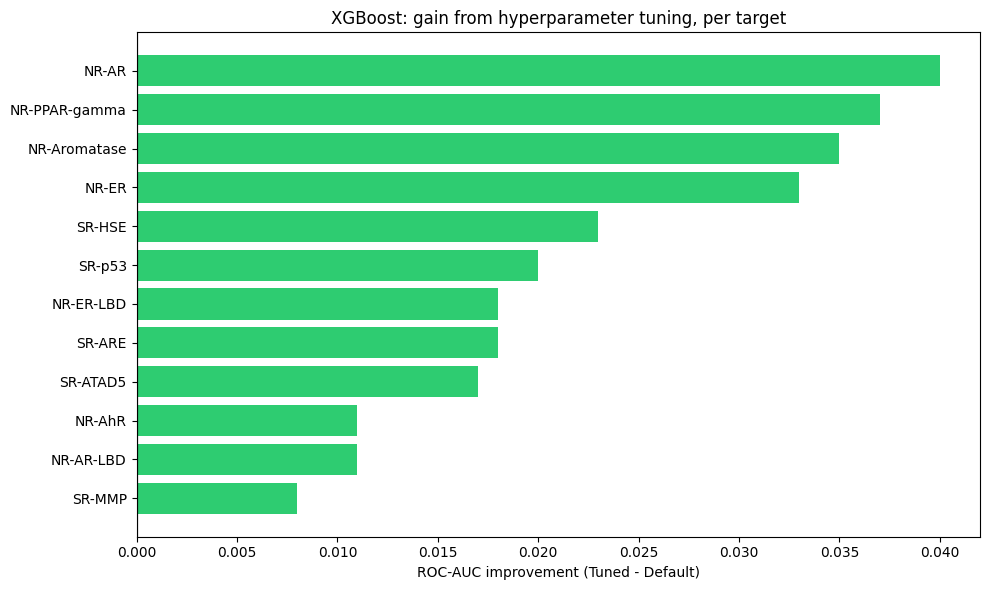

Saved!


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_xgb_compare.sort_values("Improvement")
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_plot['Improvement']]
ax.barh(df_plot['Target'], df_plot['Improvement'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("ROC-AUC improvement (Tuned - Default)")
ax.set_title("XGBoost: gain from hyperparameter tuning, per target")

plt.tight_layout()
plt.savefig("../reports/figures/xgb_tuning_improvement.png", dpi=150)
plt.show()
print("Saved!")

## Hyperparameter Tuning — Random Forest (lighter pass)

Random Forest defaults were already close to optimal in our CV results, so we use a smaller search space and fewer iterations — just to confirm there's no easy gain left on the table.

In [23]:
rf_param_dist = {
    "n_estimators": randint(150, 400),
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": randint(1, 5),
    "max_features": ['sqrt', 'log2'],
}

best_rf_params = {}
tuned_rf_scores = {}

for i, target in enumerate(targets):
    print(f"Tuning Random Forest on {target}...")
    mask = ~np.isnan(y[:, i])
    X_t = X[mask]
    y_t = y[mask, i].astype(int)

    rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        rf_base, rf_param_dist,
        n_iter=12,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_t, y_t)

    best_rf_params[target] = search.best_params_
    tuned_rf_scores[target] = search.best_score_
    print(f"  -> Best ROC-AUC: {search.best_score_:.3f}")

print("\nAll targets tuned for RF!")

Tuning Random Forest on NR-AR...
  -> Best ROC-AUC: 0.816
Tuning Random Forest on NR-AR-LBD...
  -> Best ROC-AUC: 0.873
Tuning Random Forest on NR-AhR...
  -> Best ROC-AUC: 0.891
Tuning Random Forest on NR-Aromatase...
  -> Best ROC-AUC: 0.825
Tuning Random Forest on NR-ER...
  -> Best ROC-AUC: 0.731
Tuning Random Forest on NR-ER-LBD...
  -> Best ROC-AUC: 0.807
Tuning Random Forest on NR-PPAR-gamma...
  -> Best ROC-AUC: 0.830
Tuning Random Forest on SR-ARE...
  -> Best ROC-AUC: 0.810
Tuning Random Forest on SR-ATAD5...
  -> Best ROC-AUC: 0.858
Tuning Random Forest on SR-HSE...
  -> Best ROC-AUC: 0.776
Tuning Random Forest on SR-MMP...
  -> Best ROC-AUC: 0.870
Tuning Random Forest on SR-p53...
  -> Best ROC-AUC: 0.844

All targets tuned for RF!


## Default vs Tuned — Random Forest Comparison Table

In [24]:
rf_default_scores = df_cv[df_cv['Model'] == 'Random Forest'].set_index('Target')['ROC-AUC mean']

rf_comparison_rows = []
for target in targets:
    default_score = rf_default_scores[target]
    tuned_score = tuned_rf_scores[target]
    rf_comparison_rows.append({
        "Target": target,
        "RF Default ROC-AUC": round(default_score, 3),
        "RF Tuned ROC-AUC": round(tuned_score, 3),
        "Improvement": round(tuned_score - default_score, 3),
    })

df_rf_compare = pd.DataFrame(rf_comparison_rows).sort_values("Improvement", ascending=False)
print(df_rf_compare)
df_rf_compare.to_csv("../reports/rf_default_vs_tuned.csv", index=False)
print("\nSaved!")

           Target  RF Default ROC-AUC  RF Tuned ROC-AUC  Improvement
0           NR-AR               0.786             0.816        0.030
1       NR-AR-LBD               0.849             0.873        0.024
4           NR-ER               0.717             0.731        0.014
3    NR-Aromatase               0.821             0.825        0.004
8        SR-ATAD5               0.854             0.858        0.004
7          SR-ARE               0.806             0.810        0.004
2          NR-AhR               0.890             0.891        0.001
5       NR-ER-LBD               0.807             0.807        0.000
9          SR-HSE               0.777             0.776       -0.001
6   NR-PPAR-gamma               0.834             0.830       -0.004
10         SR-MMP               0.876             0.870       -0.006
11         SR-p53               0.855             0.844       -0.011

Saved!


## Final Rebuilt Comparison — Best Tuned Model per Target

This combines tuned XGBoost, tuned Random Forest, and the CV Logistic Regression baseline (not tuned, since it was never competitive) into one final results table — this is the table to use in your report going forward.

In [25]:
lr_scores = df_cv[df_cv['Model'] == 'Logistic Reg'].set_index('Target')['ROC-AUC mean']

final_rows = []
for target in targets:
    final_rows.append({"Target": target, "Model": "Random Forest (tuned)", "ROC-AUC": round(tuned_rf_scores[target], 3)})
    final_rows.append({"Target": target, "Model": "XGBoost (tuned)", "ROC-AUC": round(tuned_xgb_scores[target], 3)})
    final_rows.append({"Target": target, "Model": "Logistic Reg (CV)", "ROC-AUC": round(lr_scores[target], 3)})

df_final = pd.DataFrame(final_rows)
df_final_pivot = df_final.pivot_table(index='Target', columns='Model', values='ROC-AUC')
print(df_final_pivot)
df_final.to_csv("../reports/final_tuned_comparison.csv", index=False)
print("\nSaved!")

Model          Logistic Reg (CV)  Random Forest (tuned)  XGBoost (tuned)
Target                                                                  
NR-AR                      0.771                  0.816            0.805
NR-AR-LBD                  0.856                  0.873            0.860
NR-AhR                     0.859                  0.891            0.883
NR-Aromatase               0.778                  0.825            0.813
NR-ER                      0.680                  0.731            0.718
NR-ER-LBD                  0.776                  0.807            0.795
NR-PPAR-gamma              0.784                  0.830            0.801
SR-ARE                     0.762                  0.810            0.789
SR-ATAD5                   0.811                  0.858            0.832
SR-HSE                     0.716                  0.776            0.759
SR-MMP                     0.852                  0.870            0.870
SR-p53                     0.782                  0

## Final Heatmap — Tuned Models

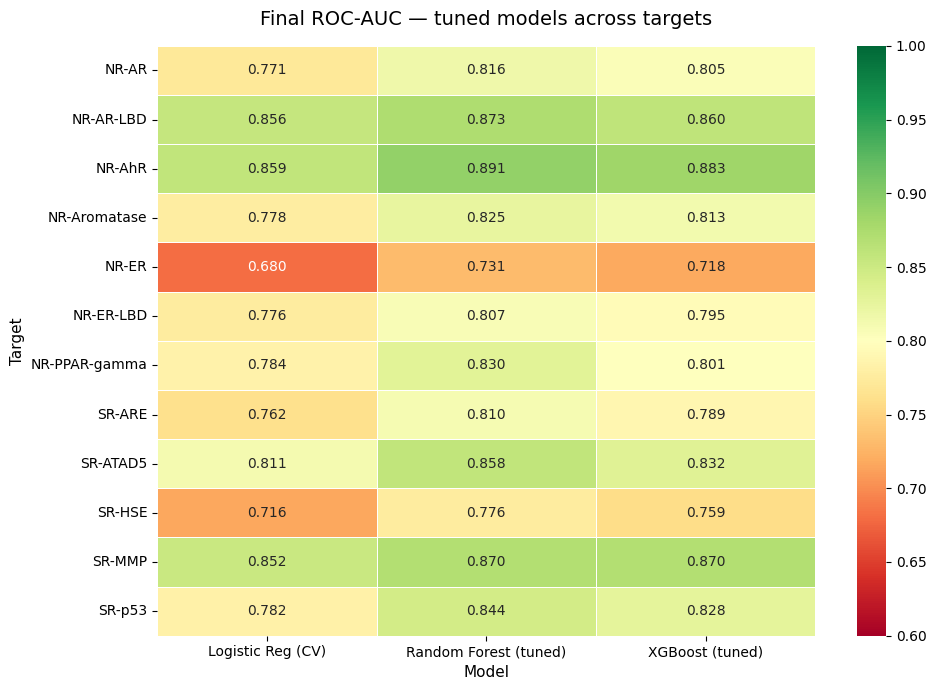

Saved!


In [26]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df_final_pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.6, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("Final ROC-AUC — tuned models across targets", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Target", fontsize=11)
plt.tight_layout()
plt.savefig("../reports/figures/final_tuned_heatmap.png", dpi=150)
plt.show()
print("Saved!")

In [27]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

final_rf_models = {}

for i, target in enumerate(targets):
    mask = ~np.isnan(y[:, i])
    X_t = X[mask]
    y_t = y[mask, i].astype(int)

    params = best_rf_params[target]
    model = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1)
    model.fit(X_t, y_t)

    final_rf_models[target] = model
    joblib.dump(model, f"../models/rf_{target}.joblib")
    print(f"Saved model for {target}")

print("\nAll final models saved!")

Saved model for NR-AR
Saved model for NR-AR-LBD
Saved model for NR-AhR
Saved model for NR-Aromatase
Saved model for NR-ER
Saved model for NR-ER-LBD
Saved model for NR-PPAR-gamma
Saved model for SR-ARE
Saved model for SR-ATAD5
Saved model for SR-HSE
Saved model for SR-MMP
Saved model for SR-p53

All final models saved!


## Feature Importance — Get Importances from Best Target

In [28]:
target_name = "NR-AhR"  # your best-performing target
model = final_rf_models[target_name]

importances = model.feature_importances_
print(f"Number of features: {len(importances)}")
print(f"Sum of importances: {importances.sum():.3f}")  # should be ~1.0
print(f"Top importance value: {importances.max():.4f}")

Number of features: 2048
Sum of importances: 1.000
Top importance value: 0.0419


## Top 15 Most Important Fingerprint Bits

In [29]:
top_n = 15
top_indices = importances.argsort()[::-1][:top_n]
top_values = importances[top_indices]

for idx, val in zip(top_indices, top_values):
    print(f"Bit {idx}: importance = {val:.4f}")

Bit 1750: importance = 0.0419
Bit 1873: importance = 0.0387
Bit 1380: importance = 0.0380
Bit 875: importance = 0.0255
Bit 1457: importance = 0.0177
Bit 1855: importance = 0.0163
Bit 80: importance = 0.0160
Bit 1199: importance = 0.0115
Bit 1088: importance = 0.0110
Bit 378: importance = 0.0108
Bit 1171: importance = 0.0101
Bit 1357: importance = 0.0090
Bit 1573: importance = 0.0082
Bit 1816: importance = 0.0082
Bit 1057: importance = 0.0076


## Visualize Top 15 Feature Importances

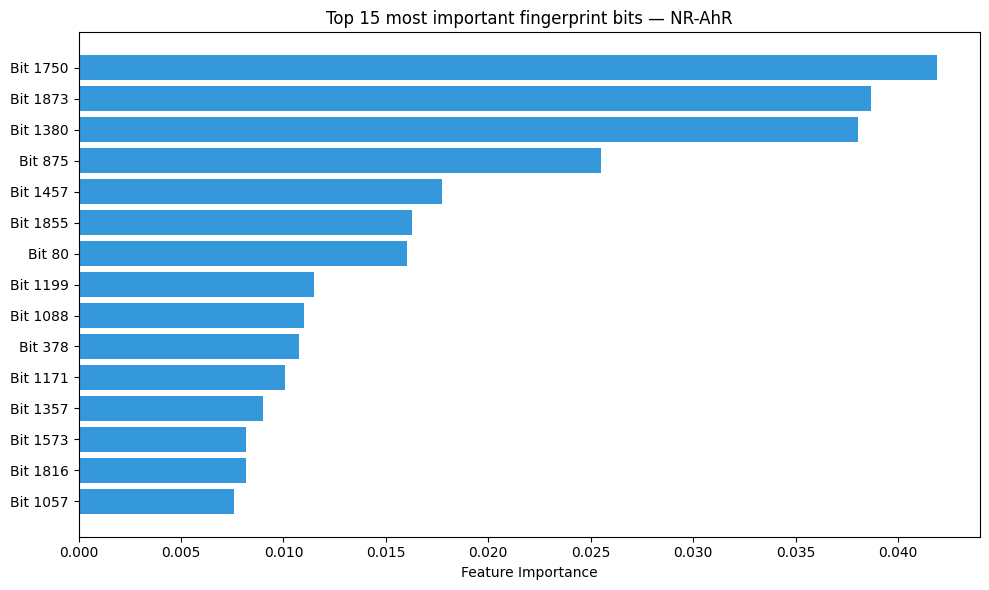

Saved!


In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([f"Bit {idx}" for idx in top_indices[::-1]], top_values[::-1], color='#3498db')
ax.set_xlabel("Feature Importance")
ax.set_title(f"Top {top_n} most important fingerprint bits — {target_name}")

plt.tight_layout()
plt.savefig("../reports/figures/feature_importance_top15.png", dpi=150)
plt.show()
print("Saved!")

## Map Top Bit to Molecules Containing It

In [31]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D

df = pd.read_csv("../data/raw/tox21.csv.gz")
smiles_list = df['smiles'].values

# Find molecules that actually have Bit 1750 turned ON
bit_to_explain = top_indices[0]  # the #1 most important bit
example_mols = []

for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=info)
    if bit_to_explain in info:
        example_mols.append((mol, info[bit_to_explain]))
    if len(example_mols) >= 4:
        break

print(f"Found {len(example_mols)} molecules containing bit {bit_to_explain}")

Found 4 molecules containing bit 1750


[04:28:48] DEPRECATION WARNING: please use MorganGenerator
[04:28:48] DEPRECATION WARNING: please use MorganGenerator
[04:28:48] DEPRECATION WARNING: please use MorganGenerator
[04:28:48] DEPRECATION WARNING: please use MorganGenerator
[04:28:48] DEPRECATION WARNING: please use MorganGenerator
[04:28:48] DEPRECATION WARNING: please use MorganGenerator
[04:28:48] DEPRECATION WARNING: please use MorganGenerator


## Draw Highlighted Substructure on Example Molecule

In [32]:
from rdkit.Chem.Draw import rdMolDraw2D

imgs = []
for mol, atom_envs in example_mols:
    atom_idx, radius = atom_envs[0]  # take the first environment found
    if radius == 0:
        atoms_to_highlight = [atom_idx]
        bonds_to_highlight = []
    else:
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        atoms_to_highlight = list(set(
            idx for bond_idx in env 
            for idx in (mol.GetBondWithIdx(bond_idx).GetBeginAtomIdx(), mol.GetBondWithIdx(bond_idx).GetEndAtomIdx())
        ))
        bonds_to_highlight = list(env)
    
    drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=atoms_to_highlight, highlightBonds=bonds_to_highlight)
    drawer.FinishDrawing()
    imgs.append(drawer.GetDrawingText())

# Save first one to view
with open("../reports/figures/bit_1750_example.png", "wb") as f:
    f.write(imgs[0])

print("Saved! Open reports/figures/bit_1750_example.png to view")

Saved! Open reports/figures/bit_1750_example.png to view


## Compute SHAP Values for Best Target

In [39]:
import shap

target_name = "NR-AhR"
model = final_rf_models[target_name]

mask = ~np.isnan(y[:, targets.index(target_name)])
X_t = X[mask]

# Use a sample for speed — SHAP on RF can be slow on thousands of rows
sample_size = 500
X_sample = X_t[:sample_size]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

print(f"SHAP values shape: {np.array(shap_values).shape}")

SHAP values shape: (500, 2048, 2)


## SHAP Beeswarm Plot (Toxic Class)

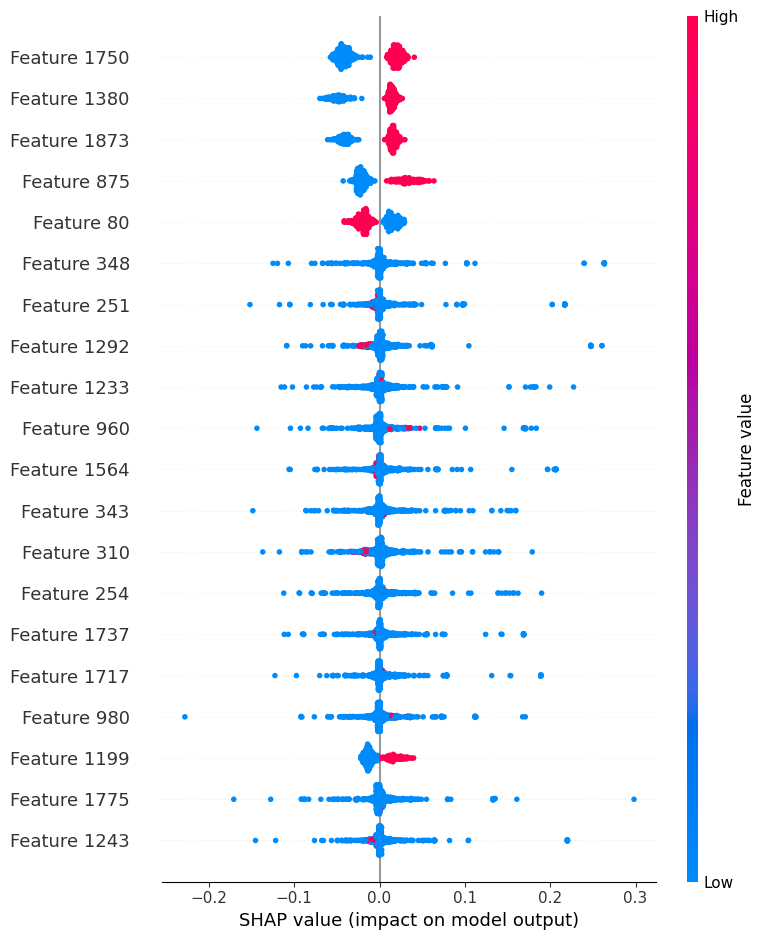

Saved!


In [36]:
shap_values_toxic = shap_values[:, :, 1]  # class 1 = toxic

shap.summary_plot(shap_values_toxic, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_beeswarm_NR-AhR.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

## Decode Bit 80 — Opposite-Direction Feature

In [38]:
bit_to_explain = 80
example_mols_80 = []

for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=info)
    if bit_to_explain in info:
        example_mols_80.append((mol, info[bit_to_explain]))
    if len(example_mols_80) >= 4:
        break

print(f"Found {len(example_mols_80)} molecules containing bit {bit_to_explain}")

mol, atom_envs = example_mols_80[0]
atom_idx, radius = atom_envs[0]

if radius == 0:
    atoms_to_highlight = [atom_idx]
    bonds_to_highlight = []
else:
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
    atoms_to_highlight = list(set(
        idx for bond_idx in env
        for idx in (mol.GetBondWithIdx(bond_idx).GetBeginAtomIdx(), mol.GetBondWithIdx(bond_idx).GetEndAtomIdx())
    ))
    bonds_to_highlight = list(env)

drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=atoms_to_highlight, highlightBonds=bonds_to_highlight)
drawer.FinishDrawing()

with open("../reports/figures/bit_80_example.png", "wb") as f:
    f.write(drawer.GetDrawingText())

print("Saved! Open reports/figures/bit_80_example.png to view")

Found 4 molecules containing bit 80
Saved! Open reports/figures/bit_80_example.png to view


[04:44:51] DEPRECATION WARNING: please use MorganGenerator
[04:44:51] DEPRECATION WARNING: please use MorganGenerator
[04:44:51] DEPRECATION WARNING: please use MorganGenerator
[04:44:51] DEPRECATION WARNING: please use MorganGenerator


## Get Test Predictions for Error Analysis (NR-AhR)

In [40]:
target_name = "NR-AhR"
target_idx = targets.index(target_name)

X_train, X_test, y_train, y_test, cw = get_target_data(X, y, target_idx=target_idx)

model_err = RandomForestClassifier(**best_rf_params[target_name], class_weight='balanced', random_state=42, n_jobs=-1)
model_err.fit(X_train, y_train)

y_pred = model_err.predict(X_test)
y_proba = model_err.predict_proba(X_test)[:, 1]

print(f"Test set size: {len(y_test)}")
print(f"Predictions done!")

Test set size: 1310
Predictions done!


## Identify False Positives and False Negatives

In [41]:
false_positives = np.where((y_pred == 1) & (y_test == 0))[0]
false_negatives = np.where((y_pred == 0) & (y_test == 1))[0]

print(f"False positives (predicted toxic, actually non-toxic): {len(false_positives)}")
print(f"False negatives (predicted non-toxic, actually toxic): {len(false_negatives)}")
print(f"Total test set: {len(y_test)}")
print(f"Total correct: {(y_pred == y_test).sum()}")

False positives (predicted toxic, actually non-toxic): 120
False negatives (predicted non-toxic, actually toxic): 52
Total test set: 1310
Total correct: 1138


## Find Most Confident Misclassifications

In [42]:
# Most confident false positives — model was SURE it was toxic, but wasn't
fp_confidence = y_proba[false_positives]
worst_fp = false_positives[np.argsort(fp_confidence)[::-1][:3]]

# Most confident false negatives — model was SURE it was safe, but wasn't
fn_confidence = y_proba[false_negatives]
worst_fn = false_negatives[np.argsort(fn_confidence)[:3]]

print("Most confident FALSE POSITIVES (predicted toxic, probability):")
for idx in worst_fp:
    print(f"  Index {idx}: probability = {y_proba[idx]:.3f}")

print("\nMost confident FALSE NEGATIVES (predicted non-toxic, probability):")
for idx in worst_fn:
    print(f"  Index {idx}: probability = {y_proba[idx]:.3f}")

Most confident FALSE POSITIVES (predicted toxic, probability):
  Index 465: probability = 0.863
  Index 1153: probability = 0.860
  Index 396: probability = 0.834

Most confident FALSE NEGATIVES (predicted non-toxic, probability):
  Index 584: probability = 0.058
  Index 3: probability = 0.135
  Index 48: probability = 0.148


## Map Misclassified Indices to SMILES

In [43]:
# Get the original SMILES for the test set so we can look up these specific molecules
mask_target = ~np.isnan(y[:, target_idx])
smiles_target = df['smiles'].values[mask_target]

# Re-derive the same train/test split to map indices back to SMILES
from sklearn.model_selection import train_test_split
_, smiles_test = train_test_split(smiles_target, test_size=0.2, random_state=42, stratify=y[mask_target, target_idx].astype(int))

print("Worst False Positives (model said toxic, actually non-toxic):")
for idx in worst_fp:
    print(f"  {smiles_test[idx]}  (confidence: {y_proba[idx]:.3f})")

print("\nWorst False Negatives (model said non-toxic, actually toxic):")
for idx in worst_fn:
    print(f"  {smiles_test[idx]}  (confidence: {y_proba[idx]:.3f})")

Worst False Positives (model said toxic, actually non-toxic):
  COc1cc(-c2ccc(N)c(OC)c2)ccc1N  (confidence: 0.863)
  c1ccc2sc(SSc3nc4ccccc4s3)nc2c1  (confidence: 0.860)
  COc1ccc(N)c(C)c1  (confidence: 0.834)

Worst False Negatives (model said non-toxic, actually toxic):
  CC12CCC(CC1)C(C)(C)O2  (confidence: 0.058)
  CCCC[n+]1ccc(C)cc1  (confidence: 0.135)
  CCCCCCOC(=O)c1ccccc1C(=O)OCCCCCC  (confidence: 0.148)


## Draw Worst False Positives and False Negatives

In [45]:
fp_smiles = ['COc1cc(-c2ccc(N)c(OC)c2)ccc1N', 'c1ccc2sc(SSc3nc4ccccc4s3)nc2c1', 'COc1ccc(N)c(C)c1']
fn_smiles = ['CC12CCC(CC1)C(C)(C)O2', 'CCCC[n+]1ccc(C)cc1', 'CCCCCCOC(=O)c1ccccc1C(=O)OCCCCCC']

fp_mols = [Chem.MolFromSmiles(s) for s in fp_smiles]
fn_mols = [Chem.MolFromSmiles(s) for s in fn_smiles]

img_fp = Draw.MolsToGridImage(fp_mols, molsPerRow=3, subImgSize=(250,250), 
                                legends=[f"FP: {p:.2f}" for p in y_proba[worst_fp]],
                                returnPNG=False)
img_fp.save("../reports/figures/worst_false_positives.png")

img_fn = Draw.MolsToGridImage(fn_mols, molsPerRow=3, subImgSize=(250,250), 
                                legends=[f"FN: {p:.2f}" for p in y_proba[worst_fn]],
                                returnPNG=False)
img_fn.save("../reports/figures/worst_false_negatives.png")

print("Saved both! Open the images to view")

Saved both! Open the images to view


In [47]:
summary_rows = []

for i, target in enumerate(targets):
    rf_score = tuned_rf_scores[target]
    xgb_score = tuned_xgb_scores[target]
    lr_score = lr_scores[target]
    
    best_model_name = max([("Random Forest", rf_score), ("XGBoost", xgb_score), ("Logistic Reg", lr_score)], key=lambda x: x[1])
    
    summary_rows.append({
        "Target": target,
        "Best Model": best_model_name[0],
        "Best ROC-AUC": round(best_model_name[1], 3),
        "RF ROC-AUC": round(rf_score, 3),
        "XGBoost ROC-AUC": round(xgb_score, 3),
        "LogReg ROC-AUC": round(lr_score, 3),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv("../reports/final_summary_table.csv", index=False)
print(df_summary)

           Target     Best Model  Best ROC-AUC  RF ROC-AUC  XGBoost ROC-AUC  \
0           NR-AR  Random Forest         0.816       0.816            0.805   
1       NR-AR-LBD  Random Forest         0.873       0.873            0.860   
2          NR-AhR  Random Forest         0.891       0.891            0.883   
3    NR-Aromatase  Random Forest         0.825       0.825            0.813   
4           NR-ER  Random Forest         0.731       0.731            0.718   
5       NR-ER-LBD  Random Forest         0.807       0.807            0.795   
6   NR-PPAR-gamma  Random Forest         0.830       0.830            0.801   
7          SR-ARE  Random Forest         0.810       0.810            0.789   
8        SR-ATAD5  Random Forest         0.858       0.858            0.832   
9          SR-HSE  Random Forest         0.776       0.776            0.759   
10         SR-MMP        XGBoost         0.870       0.870            0.870   
11         SR-p53  Random Forest         0.844      

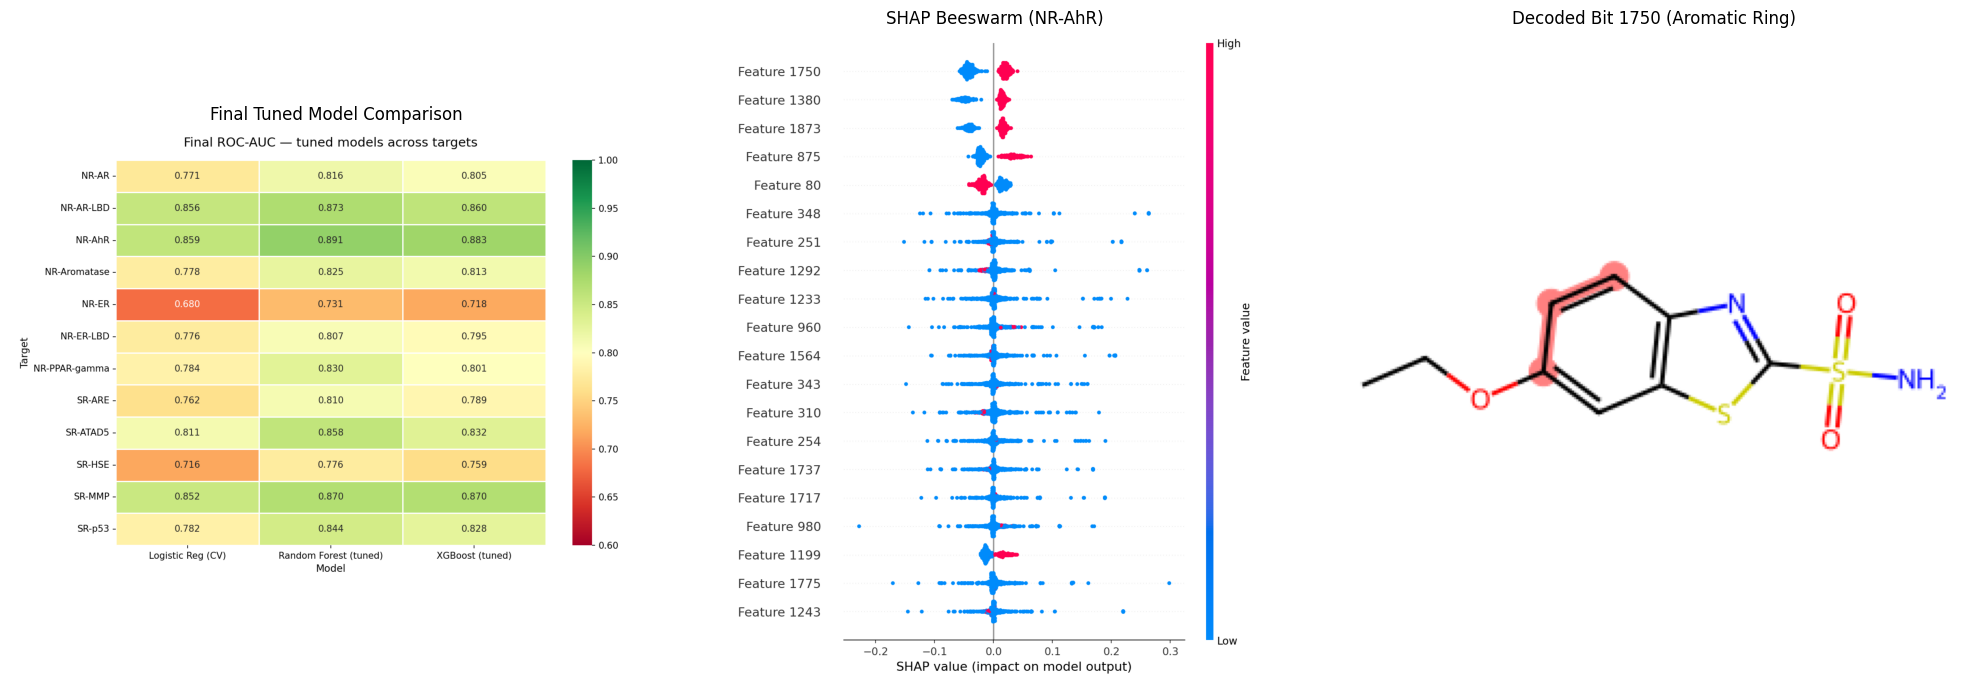

Saved!


In [48]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

img1 = mpimg.imread("../reports/figures/final_tuned_heatmap.png")
img2 = mpimg.imread("../reports/figures/shap_beeswarm_NR-AhR.png")
img3 = mpimg.imread("../reports/figures/bit_1750_example.png")

axes[0].imshow(img1)
axes[0].set_title("Final Tuned Model Comparison", fontsize=12)
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title("SHAP Beeswarm (NR-AhR)", fontsize=12)
axes[1].axis('off')

axes[2].imshow(img3)
axes[2].set_title("Decoded Bit 1750 (Aromatic Ring)", fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../reports/figures/final_summary_grid.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [49]:
best_target = df_summary.loc[df_summary['Best ROC-AUC'].idxmax()]
worst_target = df_summary.loc[df_summary['Best ROC-AUC'].idxmin()]
rf_wins = (df_summary['Best Model'] == 'Random Forest').sum()

print("="*60)
print("PROJECT SUMMARY — Tox21 QSAR Toxicity Prediction")
print("="*60)
print(f"Total molecules: {X.shape[0]}")
print(f"Feature representation: Morgan fingerprints ({X.shape[1]} bits)")
print(f"Targets evaluated: {len(targets)}")
print(f"\nBest performing target: {best_target['Target']} (ROC-AUC = {best_target['Best ROC-AUC']})")
print(f"Hardest target: {worst_target['Target']} (ROC-AUC = {worst_target['Best ROC-AUC']})")
print(f"Random Forest won on {rf_wins}/{len(targets)} targets")
print(f"\nMean ROC-AUC across all targets: {df_summary['Best ROC-AUC'].mean():.3f}")
print("="*60)

PROJECT SUMMARY — Tox21 QSAR Toxicity Prediction
Total molecules: 7831
Feature representation: Morgan fingerprints (2048 bits)
Targets evaluated: 12

Best performing target: NR-AhR (ROC-AUC = 0.891)
Hardest target: NR-ER (ROC-AUC = 0.731)
Random Forest won on 11/12 targets

Mean ROC-AUC across all targets: 0.828


In [51]:
readme_content = """# Tox21 QSAR — Molecular Toxicity Prediction

Predicting toxicity of 7,831 molecules across 12 biological targets
using Morgan fingerprints (RDKit) and classical ML (Random Forest, XGBoost, Logistic Regression).

## Results Summary
- Mean ROC-AUC across all targets: 0.828
- Best target: NR-AhR (ROC-AUC = 0.891)
- Hardest target: NR-ER (ROC-AUC = 0.731)
- Random Forest (tuned) was the best model on 11/12 targets

## Methodology
1. Data exploration and class imbalance analysis (Tox21, 12 targets)
2. Morgan fingerprint feature engineering (radius=2, 2048 bits)
3. Per-target missing value masking and class weight computation
4. 5-fold stratified cross-validation (Random Forest, XGBoost, Logistic Regression)
5. Hyperparameter tuning via RandomizedSearchCV
6. Feature importance analysis with chemical substructure decoding
7. SHAP interpretability analysis
8. Error analysis on misclassified molecules

## Key Finding
The model's dominant learned signal is the presence of extended aromatic
ring systems (e.g. Bit 1750), consistent with known AhR pathway biology.
False positives and false negatives both trace back to this single signal:
over-generalization on aromatic-but-non-toxic molecules, and under-detection
of non-aromatic toxicity mechanisms.

## Project structure
- `data/`       → raw and processed datasets
- `notebooks/`  → step-by-step analysis notebooks
- `src/`        → reusable Python modules
- `models/`     → saved tuned model files
- `reports/`    → figures and final report
"""

with open("../README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README updated!")

README updated!
